# CS 790 Final Project — Project 2: Hand Osteoarthritis Severity Classification

**Group 10 — Brandon Halig, Gihyun Derek Kim**
MET CS 790: Computer Vision in AI — Boston University — Prof. Ming Zhang

---

## Assignment overview

This notebook implements the **Hand OA Severity Classification** track of the CS 790 final project. The task is to train a model that takes a cropped finger-joint X-ray as input and predicts its **Kellgren–Lawrence (KL) grade (0–4)** — the standard radiographic measure of OA severity.

The brief specifies:

- Using **direct multi-class classification**.
- Handling **severe class imbalance** in the clinical data — the central challenge of this track.
- Evaluating with **ROC curves and AUC** as the primary metric.
- Demonstrating the broader skill of working with real-world clinical data: patient-level structure, missing labels, expert-graded ground truth, and uneven joint-type distributions.

The downstream goal of the broader course project is to build automated tools that replicate expert radiographic OA scoring; this notebook contributes the severity-classifier piece.


## Background

### Osteoarthritis (OA) and hand OA

**Hand OA (HOA)** is particularly debilitating because it directly impairs grip, pinch, and fine motor function — the things you need for daily activities. There is no cure. Diagnosis and progression-tracking depend on a combination of patient-reported symptoms, physical exam, and — crucially for this project — **radiographic imaging**.

### How HOA is scored from X-rays

Radiologists evaluate hand X-rays using several established scoring systems. The dataset for this project includes four:

| System                       | Scale  | What it measures                           |
|------------------------------|--------|--------------------------------------------|
| **Kellgren–Lawrence (KL)**   | 0–4    | Overall OA severity *(our target)*         |
| Joint Space Narrowing (JSN)  | 0–3    | Decrease in space between bones            |
| Osteophyte (OP)              | 0–3    | Presence of bone spurs                     |
| Erosion (ER)                 | 0 or 1 | Presence of bone erosion                   |

The **Kellgren–Lawrence scale** is the most widely used standard. Grade 0 is no OA; grade 4 is severe OA with marked joint-space narrowing, large osteophytes, and definite bony deformity. KL grading is performed manually by trained clinicians, which makes it labor-intensive and subject to inter-observer variability — radiologists frequently disagree on adjacent grades (KL 1 vs KL 2, KL 2 vs KL 3).


## Data

### Source and scope

The dataset is a private collection assembled through a Boston University ↔ Tufts Medical Center research collaboration:

- **3,590 patients/hands**, imaged at two time points (baseline `v00` and 6-year follow-up `v06`). For this project we use **only `v00` baseline** images — the classifier looks at one X-ray at a time, not a longitudinal pair.
- **41,060 joint-level ROI images** — pre-cropped and rotated to be square and vertically aligned.
- **`hand.csv`** holds all per-joint expert scores (KL, JSN, OP, ER) keyed by patient `id` and joint name.

### Joint anatomy

Each hand contributes up to **12 finger joints** (the thumb is excluded):

- **DIP** — distal interphalangeal joints, fingers 2–5 (`dip2`, `dip3`, `dip4`, `dip5`)
- **PIP** — proximal interphalangeal joints, fingers 2–5 (`pip2`–`pip5`)
- **MCP** — metacarpophalangeal joints, fingers 2–5 (`mcp2`–`mcp5`)

Finger numbering goes index → pinky (2 = index, 5 = pinky). Filenames on disk are `{patient_id}_{joint}{finger}.png`, e.g. `9000099_dip2.png`.

The three joint types are not equally affected by HOA — DIP joints are typically the *first* and most prominently affected in HOA, while MCP joints (especially MCP 4 and 5) are predominantly healthy. The per-joint-type accuracy breakdown later in the notebook lets us check whether the model is leaning on the easier joint types.

### Labels and class distribution

We use the **KL grade (0–4)** as the single classification target. Across the ~43k joint observations in the original dataset, KL grades are heavily skewed toward healthy:

| Grade  | Approx. count | Approx. share |
|--------|---------------|---------------|
| KL 0   | 31,794        | 73.9%         |
| KL 1   | 4,641         | 10.8%         |
| KL 2   | 5,545         | 12.9%         |
| KL 3   | 815           |  1.9%         |
| KL 4   | 241           |  0.6%         |

That is a **~132 : 1 imbalance ratio** between the most common class (KL 0) and the rarest (KL 4) — the central challenge for this track and the reason a vanilla cross-entropy classifier collapses to "always predict KL 0." Our actual training distribution after dropping rows with missing PNGs / missing labels is plotted in Stage 1 below.

### Other "real-world clinical data" headaches

- **Patient-level structure.** A single patient contributes up to 12 joint ROIs that are *not* independent — they share anatomy, exposure, and disease background. A naive image-level split would leak information. We split *patients* and stratify on each patient's worst KL grade.
- **Missing labels.** A small number of joints lack KL annotations; we filter those out at record-build time.
- **Missing PNGs.** Some `hand.csv` rows reference filenames that aren't on disk; we drop those too and log the count.
- **Joint-type heterogeneity.** ROI sizes differ across DIP / PIP / MCP because the underlying joints are different sizes. We resize everything to 224 × 224 for the CNN.


## Project solution

### Approach: direct multi-class classification with transfer learning

We frame KL grading as **direct multi-class classification** — five output logits, softmax, predict the argmax.

KL grades are technically *ordinal* (KL 1 is "closer to" KL 2 than to KL 4), and ordinal regression would explicitly model that. We discuss this tradeoff in the closing section and treat ordinal regression as a future-work direction; direct multi-class with class-weighted focal loss already covers most of the imbalance / hard-example handling that ordinal regression would buy us, without the extra complexity.

### Pipeline (matches the proposal's four-stage design)

1. **Data Preparation.** Read `hand.csv`, build `(filename, KL label, patient id)` records that have both a valid KL score and a PNG on disk; plot the empirical KL distribution; **patient-level stratified 70 / 15 / 15 split** on each patient's worst KL grade so severe cases are spread across train / val / test and no patient leaks across splits.
2. **Feature Extraction.** ImageNet-pretrained CNN backbone (selectable via `MODEL_NAME`: ResNet-50 or EfficientNet-B2) with the final classifier replaced by `Dropout(0.4) → Linear(…, 5)`. We fine-tune the entire network — the medical-imaging domain is far enough from ImageNet that letting lower layers adapt helps.
3. **Training.** Class-weighted **focal loss** (Lin et al., 2017) — `α_c · (1 − p_t)^γ · (−log p_t)` with `α_c = √(N_max / N_c)` and `γ = 2`. AdamW (`lr = 1e-4`, `weight_decay = 1e-4`) with cosine annealing. Mixed-precision via `autocast` + `GradScaler`. Early stopping on validation macro-AUC with patience = 8.
4. **Evaluation.** On the held-out test set: **macro-AUC (one-vs-rest)** and per-class AUC (the assignment's primary metric), per-class ROC curves, classification report, confusion matrix, per-joint-type accuracy (DIP / PIP / MCP), a sample-prediction gallery (correct vs incorrect, all KL grades), and **Grad-CAM** heatmaps for interpretability.

### Key design choices and why

- **Macro-AUC as the headline metric.** The brief asks for ROC / AUC. Under 132 : 1 imbalance, *accuracy* is misleading (predicting always-KL0 already gets ~74%). Macro-AUC averages one-vs-rest AUC across all five KL grades equally, so KL 4 counts as much as KL 0.
- **Patient-level stratified splitting.** Stratifying on each patient's *worst* KL grade keeps the few KL 3 / KL 4 patients spread across train / val / test rather than all landing in one bucket, while the patient-level grouping prevents a patient's left and right hands from landing in different splits.
- **Class-weighted focal loss instead of plain weighted cross-entropy.** Focal loss adds a `(1 − p_t)^γ` factor that down-weights *easy* examples (the abundant, correctly-classified KL 0s) and concentrates gradient on hard / minority cases — exactly what we want under heavy imbalance.
- **Both ResNet-50 and EfficientNet-B2 supported.** The proposal commits to comparing both. The notebook ships with `MODEL_NAME = 'resnet50'`; flip it to `'efficientnet_b2'` and re-run for the head-to-head.
- **Grad-CAM (Selvaraju et al., 2017) for interpretability.** A KL classifier that's accurate but ignores anatomy isn't clinically trustworthy. The Grad-CAM panels at the end let us check that attention concentrates on the joint space and bone edges — the same features a radiologist looks at.

---


## User Manual

### What this notebook does
Given a cropped X-ray of a single finger joint, predicts the KL severity grade (0–4). All outputs render inline so they save with the notebook.

### Prerequisites
- Google account, Colab GPU runtime (free T4 is enough; A100 / L4 is faster).
- Hand OA dataset on your Drive: a folder of joint-ROI PNGs and `hand.csv`.
  - [Photos](https://drive.google.com/file/d/1yrJWaeZVDyutm61LbbRozc6gY8XvofEb/view?usp=sharing)
  - [CSV](https://docs.google.com/spreadsheets/d/1HLXDqLjtT4Dfl7XZZZ409qUPT5ZrsgAf/edit?usp=sharing&ouid=115422732134383892205&rtpof=true&sd=true)

### Drive layout
Upload the dataset to your Drive in this layout (or change `IMG_DIR` / `CSV_PATH` in the Configuration cell to match yours):

```
MyDrive/
└── HandOA/
    ├── hand.csv                    ← KL/JSN/OP/ER scores
    └── FingerJoints/               ← joint-ROI PNGs
        ├── 9000099_dip2.png
        ├── 9000099_dip3.png
        ├── ...
        └── 9999878_mcp5.png
```

Filenames are `{patient_id}_{joint}{finger#}.png`, joint ∈ `dip2…dip5`, `pip2…pip5`, `mcp2…mcp5` (lowercase), finger# ∈ 2–5 (index → pinky; no thumb).

### How to run
1. Open this notebook in Colab (`File → Upload notebook`).
2. Switch to a GPU runtime: `Runtime → Change runtime type → Hardware accelerator → GPU`.
3. Run the cells top to bottom (`Shift + Enter`) or use `Runtime → Run all`. The first cell mounts your Drive — accept the auth prompt.

### Configuration knobs
All settings live in the Configuration cell. The most useful ones:

| Setting        | Default       | Purpose                                                                                  |
|----------------|---------------|------------------------------------------------------------------------------------------|
| `MODEL_NAME`   | `'resnet50'`  | Backbone architecture. `'resnet50'` or `'efficientnet_b2'`.                              |
| `BATCH_SIZE`   | `64`          | Lower this if you hit CUDA OOM on a smaller GPU.                                         |
| `NUM_EPOCHS`   | `25`          | Maximum training epochs (early stopping may end sooner).                                 |
| `PATIENCE`     | `8`           | Epochs without val-AUC improvement before early stopping.                                |
| `LR`           | `1e-4`        | Learning rate for AdamW.                                                                 |
| `CACHE_IN_RAM` | `True`        | Caches PNGs in RAM after first load — much faster than re-reading from Drive each epoch. |
| `MAX_PATIENTS` | `None`        | Set to a small int (e.g. `250`) to subsample for fast iteration.                         |
| `SEED`         | `790`         | Reproducibility seed.                                                                    |


### First-run timing
Caching ~41k PNGs from Drive to RAM takes many hours the first time because Drive throttles many small reads. Subsequent epochs are fast because everything stays in RAM. To iterate quickly, set `MAX_PATIENTS = 250` — only ~2,800 images get loaded.

### Outputs
All outputs render inline and are saved with the notebook:
- KL distribution bar chart
- Training-progress prints + best-epoch flag, training-convergence plot
- **ROC curves (one-vs-rest, per KL grade) + macro-AUC** — the primary metric
- Per-class AUC table, classification report, confusion matrix heatmap
- Per-joint-type accuracy (DIP / PIP / MCP)
- Sample test predictions (correct + incorrect, all KL grades)
- Grad-CAM heatmaps (≥ 2 examples per KL grade)

### Troubleshooting
- *`FileNotFoundError`* — make sure `IMG_DIR` and `CSV_PATH` match your Drive paths.
- *`MemoryError` during caching* — set `CACHE_IN_RAM = False`.
- *`CUDA out of memory`* — lower `BATCH_SIZE` to 32 or 16.
- *Drive mount keeps prompting* — make sure you're logged into the same Google account that owns the dataset folder.

---


## Setup

In [ ]:
# Mount Google Drive so we can read hand.csv and the joint-ROI PNGs
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, accuracy_score,
)
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from concurrent.futures import ThreadPoolExecutor

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration

Adjust paths if your Drive layout is different. **For the final run, set `MAX_PATIENTS = None`** so the model trains on the full ~41k images. `MAX_PATIENTS = 250` is just for fast iteration during development.

In [ ]:
# Paths
IMG_DIR  = "/content/drive/MyDrive/HandOA/FingerJoints"
CSV_PATH = "/content/drive/MyDrive/HandOA/hand.csv"

# Model selection: 'resnet50' or 'efficientnet_b2'
MODEL_NAME   = 'resnet50'

# Training hyperparameters
BATCH_SIZE   = 64
NUM_EPOCHS   = 25
PATIENCE     = 8            # early-stop patience on val macro-AUC
LR           = 1e-4
SEED         = 790
NUM_CLASSES  = 5            # KL grades 0..4

# Speed knobs
CACHE_IN_RAM = True         # cache decoded PNGs in RAM after first load
MAX_PATIENTS = None         # None = full dataset; set to e.g. 250 for fast iteration
NUM_WORKERS  = 0 if CACHE_IN_RAM else 4

JOINTS = ['DIP2','DIP3','DIP4','DIP5',
          'PIP2','PIP3','PIP4','PIP5',
          'MCP2','MCP3','MCP4','MCP5']

torch.manual_seed(SEED); np.random.seed(SEED); torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}   Model: {MODEL_NAME}   Batch: {BATCH_SIZE}   Epochs (max): {NUM_EPOCHS}")
print(f"Cache in RAM: {CACHE_IN_RAM}   MAX_PATIENTS: {MAX_PATIENTS}")

def fmt_time(s):
    h, rem = divmod(int(s), 3600); m, s = divmod(rem, 60)
    return f"{h:d}h{m:02d}m{s:02d}s" if h else f"{m:d}m{s:02d}s"


Device: cuda   Model: resnet50   Batch: 64   Epochs (max): 25
Cache in RAM: True   MAX_PATIENTS: None


## Stage 1 — Data Preparation

Load `hand.csv`, build `(filename, KL label, patient id)` records that have both a valid KL score (0–4) and a PNG on disk, plot the KL distribution, then split **patients** 70 / 15 / 15 — stratified on each patient's worst KL grade so no patient leaks across splits and severe cases are spread across train / val / test.

In [ ]:
print("Stage 1: Data Preparation")
print("=" * 60)
t_stage1 = time.time()

full_df = pd.read_csv(CSV_PATH)
valid_files = set(os.listdir(IMG_DIR)) if os.path.exists(IMG_DIR) else set()

# Optionally subsample patients for fast iteration
if MAX_PATIENTS is not None and 0 < MAX_PATIENTS < len(full_df):
    work_df = full_df.sample(n=MAX_PATIENTS, random_state=SEED).reset_index(drop=True)
    print(f"MAX_PATIENTS = {MAX_PATIENTS}: subsampling {MAX_PATIENTS} of {len(full_df)} patients")
else:
    work_df = full_df
    print(f"Using all {len(full_df)} patients")

print(f"PNG files on disk: {len(valid_files):,}")

# Build records: drop rows with missing KL labels or missing PNGs.
records, missing = [], 0
for _, row in work_df.iterrows():
    pid = int(row['id'])
    for joint in JOINTS:
        col = f"v00{joint}_KL"
        if col not in row or pd.isna(row[col]): continue
        label = int(row[col])
        if not 0 <= label <= 4: continue
        fname = f"{pid}_{joint.lower()}.png"
        if fname not in valid_files:
            missing += 1
            continue
        records.append((fname, label, pid))

records_df = pd.DataFrame(records, columns=['fname','label','pid'])
print(f"Records built: {len(records):,}   (missing PNGs: {missing})")

Stage 1: Data Preparation
Using all 3590 patients
PNG files on disk: 41,060
Records built: 41,075   (missing PNGs: 1961)


### KL grade distribution

KL 0 dominates and KL 4 is rare — this imbalance is why we use class-weighted focal loss in Stage 3.

Total joint-level annotations: 41,075

KL grade       Count   Percent
  KL 0        31,510     76.7%
  KL 1         4,539     11.1%
  KL 2         4,485     10.9%
  KL 3           308      0.7%
  KL 4           233      0.6%


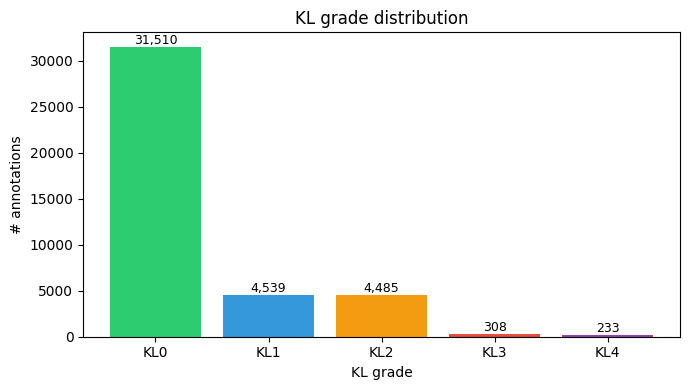

In [ ]:
# Aggregate KL distribution
kl_dist = records_df['label'].value_counts().reindex(range(NUM_CLASSES), fill_value=0)
total = int(kl_dist.sum())
print(f"Total joint-level annotations: {total:,}\n")
print(f"{'KL grade':<10}{'Count':>10}{'Percent':>10}")
for k, v in kl_dist.items():
    print(f"  KL {k}    {v:>10,}{100*v/total:>9.1f}%")

# Plot it
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#8e44ad']
ax.bar(kl_dist.index, kl_dist.values, color=colors)
for k, v in kl_dist.items():
    ax.text(k, v, f"{v:,}", ha='center', va='bottom', fontsize=9)
ax.set_xlabel("KL grade"); ax.set_ylabel("# annotations")
ax.set_title("KL grade distribution")
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels([f"KL{k}" for k in range(NUM_CLASSES)])
plt.tight_layout(); plt.show()

### Patient-level stratified train / val / test split (70 / 15 / 15)

Stratify on each patient's **worst** KL grade so the few KL 3 / KL 4 patients are split across train / val / test instead of all landing in one bucket.

In [ ]:
# Stratify on each patient's WORST KL grade so severe cases aren't all in one split
patient_max = records_df.groupby('pid')['label'].max().reset_index()

train_p, temp_p = train_test_split(
    patient_max, test_size=0.30, stratify=patient_max['label'], random_state=SEED)
val_p, test_p = train_test_split(
    temp_p,      test_size=0.50, stratify=temp_p['label'],      random_state=SEED)

def _split(pdf):
    return records_df[records_df['pid'].isin(set(pdf['pid']))][['fname','label']].values.tolist()

train_data, val_data, test_data = _split(train_p), _split(val_p), _split(test_p)

def _kl_counts(data):
    c = [0]*NUM_CLASSES
    for _, l in data: c[l] += 1
    return c

print(f"  {'Split':<6} {'Total':>7}    {'KL0':>5} {'KL1':>5} {'KL2':>5} {'KL3':>5} {'KL4':>5}")
for name, d in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    c = _kl_counts(d)
    print(f"  {name:<6} {sum(c):>7}    {c[0]:>5} {c[1]:>5} {c[2]:>5} {c[3]:>5} {c[4]:>5}")

  Split    Total      KL0   KL1   KL2   KL3   KL4
  Train    28756    22094  3160  3103   223   176
  Val       6174     4730   715   668    33    28
  Test      6145     4686   664   714    52    29


### Dataset, transforms, and DataLoaders

**Google Drive caching.** Drive's per-file reads are really slow. On first run we decode each PNG once via an 8-thread `ThreadPoolExecutor` into a module-level `shared_cache` dict; `__getitem__` then reads from RAM and applies augmentation. Module-level on purpose — re-running the cell tops up the cache instead of re-paying the multi-hour load. `CACHE_IN_RAM = False` falls back to per-`__getitem__` Drive reads (only useful for tiny `MAX_PATIENTS` runs).

**Augmentation.** Train-only: rotation ±15°, horizontal flip, brightness/contrast jitter. Horizontal flip is safe because each ROI is a single isolated joint — left-vs-right has no clinical meaning at this scale. Val/test use resize + normalize only.

**Normalization.** ImageNet mean/std so the pretrained backbone sees inputs in the distribution it was trained on.

In [ ]:
class HandOADataset(Dataset):
    """Returns (image_tensor, label). Optionally reads from an in-memory cache
    to avoid repeated Google Drive I/O during training."""
    def __init__(self, data, img_dir, transform=None, cache=None):
        self.data, self.img_dir, self.transform, self.cache = data, img_dir, transform, cache
    def __len__(self):
        return len(self.data)
    def __getitem__(self, i):
        fname, label = self.data[i]
        if self.cache is not None and fname in self.cache:
            img = self.cache[fname].copy()
        else:
            img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

def _load_pil(fname):
    img = Image.open(os.path.join(IMG_DIR, fname)).convert("RGB"); img.load(); return img

# Cache PNGs in RAM (huge speedup vs Google Drive I/O on every epoch).
# Reuses anything already cached from a previous run.
if CACHE_IN_RAM:
    shared_cache = globals().get('shared_cache')
    if not isinstance(shared_cache, dict):
        shared_cache = {}

    needed = set(f for f, _, _ in records)
    missing_in_cache = sorted(needed - shared_cache.keys())

    if missing_in_cache:
        action = "Caching" if not shared_cache else "Topping up cache with"
        print(f"{action} {len(missing_in_cache):,} images (cache had {len(shared_cache):,})...")
        cache_t0 = time.time()

        def _safe_load(fname):
            try: return fname, _load_pil(fname)
            except Exception: return fname, None

        with ThreadPoolExecutor(max_workers=8) as ex:
            for k, (fname, img) in enumerate(ex.map(_safe_load, missing_in_cache), 1):
                if img is not None:
                    shared_cache[fname] = img
                if k % 100 == 0:
                    print(f"  loaded {k:,} / {len(missing_in_cache):,}  ({fmt_time(time.time()-cache_t0)})")

        print(f"Cache now holds {len(shared_cache):,} images "
              f"(added {len(missing_in_cache):,} in {fmt_time(time.time()-cache_t0)})")
else:
    shared_cache = None

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

dl_kwargs = dict(batch_size=BATCH_SIZE, pin_memory=True,
                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
train_loader = DataLoader(HandOADataset(train_data, IMG_DIR, train_tf, shared_cache), shuffle=True,  **dl_kwargs)
val_loader   = DataLoader(HandOADataset(val_data,   IMG_DIR, eval_tf,  shared_cache), shuffle=False, **dl_kwargs)
test_loader  = DataLoader(HandOADataset(test_data,  IMG_DIR, eval_tf,  shared_cache), shuffle=False, **dl_kwargs)

print(f"Stage 1 complete in {fmt_time(time.time()-t_stage1)}")

Stage 1 complete in 0m01s


## Stage 2 — Feature Extraction (CNN backbone)

ImageNet-pretrained backbone (selected by `MODEL_NAME`: `resnet50` or `efficientnet_b2`) with the final classifier head replaced by `Dropout(0.4) → Linear(…, 5)`. We fine-tune the entire network — the medical-image domain is far enough from ImageNet that letting the lower layers adapt helps.

In [ ]:
def build_model(name: str, num_classes: int):
    """ImageNet-pretrained backbone with a Dropout + Linear head.
    Supports 'resnet50' and 'efficientnet_b2'."""
    name = name.lower()
    if name == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, num_classes))
    elif name == 'efficientnet_b2':
        m = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
        m.classifier = nn.Sequential(nn.Dropout(0.4),
                                     nn.Linear(m.classifier[-1].in_features, num_classes))
    else:
        raise ValueError(f"Unknown MODEL_NAME={name!r}; expected 'resnet50' or 'efficientnet_b2'.")
    return m

model = build_model(MODEL_NAME, NUM_CLASSES)
model = model.to(device, memory_format=torch.channels_last)
print(f"{MODEL_NAME}  |  {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 146MB/s]


resnet50  |  23.5M params


## Stage 3 — Training

**Loss.** Class-weighted **focal loss** (Lin et al., 2017): scales each example's loss by `(1 - p_t)^γ` to down-weight easy examples and concentrate gradient on hard ones, then by a per-class `α` to balance frequencies. Class weights are `α_c = √(N_max / N_c)`.

> *Implementation note:* we compute `p_t` from the unweighted softmax, **not** from the weighted cross-entropy — using `exp(-weighted_CE)` would conflate the focal `(1 - p_t)` term with the class weight and largely defeat the focal-loss modulation.

**Schedule.** AdamW (`lr = 1e-4`, `weight_decay = 1e-4`) with cosine annealing over the full epoch budget. Mixed precision (`autocast` + `GradScaler`) for speed. Early stopping on validation macro-AUC with patience = 8.

In [ ]:
# Class weights from training distribution
class_counts  = np.bincount(np.array([d[1] for d in train_data]), minlength=NUM_CLASSES).astype(float)
class_weights = torch.tensor(np.sqrt(class_counts.max() / np.clip(class_counts, 1, None)),
                             dtype=torch.float).to(device)
print(f"Class counts (train): {class_counts.astype(int).tolist()}")
print(f"Class weights:        {class_weights.cpu().numpy().round(2).tolist()}")

class FocalLoss(nn.Module):
    """Class-weighted focal loss.

    Loss_i = alpha_{y_i} * (1 - p_{y_i})^gamma * (-log p_{y_i})

    where p is the *unweighted* softmax probability. This is the form from
    Lin et al. (2017) and keeps the (1 - p_t) modulation independent of the
    per-class alpha weights.
    """
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.register_buffer('alpha', alpha)
        self.gamma = gamma
    def forward(self, logits, targets):
        log_probs   = F.log_softmax(logits, dim=1)
        log_p_t     = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        p_t         = log_p_t.exp()
        alpha_t     = self.alpha[targets]
        loss        = alpha_t * (1.0 - p_t).pow(self.gamma) * (-log_p_t)
        return loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=2.0).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler    = GradScaler('cuda')

Class counts (train): [22094, 3160, 3103, 223, 176]
Class weights:        [1.0, 2.640000104904175, 2.6700000762939453, 9.949999809265137, 11.199999809265137]


### Evaluation helper (used by the training loop and Stage 4)

We compute macro-AUC by iterating over each class one-vs-rest manually rather than relying on `roc_auc_score(..., multi_class='ovr', labels=present)` — that route silently behaves differently when not every class is present in the labels, which makes per-epoch macro-AUC numbers harder to compare. Skipping classes with zero positives is correct because AUC is undefined for a single-class label vector.

In [ ]:
@torch.no_grad()
def evaluate(loader):
    """Return (mean_loss, macro_auc, preds, labels, probs)."""
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_preds, all_labels = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        y = y.to(device, non_blocking=True)
        with autocast('cuda'):
            out  = model(x)
            loss = criterion(out, y)
        total_loss += loss.item() * x.size(0); n += x.size(0)
        probs = torch.softmax(out.float(), dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(probs.argmax(1).cpu().numpy())
        all_labels.append(y.cpu().numpy())
    probs, preds, labels = map(np.concatenate, (all_probs, all_preds, all_labels))

    # Macro-AUC: average per-class one-vs-rest AUC over classes that have
    # at least one positive AND at least one negative in this loader.
    aucs = []
    for cls in range(NUM_CLASSES):
        y_bin = (labels == cls).astype(int)
        if 0 < y_bin.sum() < len(y_bin):
            try:
                aucs.append(roc_auc_score(y_bin, probs[:, cls]))
            except ValueError:
                pass
    macro_auc = float(np.mean(aucs)) if aucs else float('nan')
    return total_loss / max(n, 1), macro_auc, preds, labels, probs

### Training loop

In [ ]:
best_auc, best_state, no_improve = -1.0, None, 0
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_auc': []}
train_start = time.time()
print(f"Training up to {NUM_EPOCHS} epochs (early-stop patience = {PATIENCE})\n")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running, seen, n_batches = 0.0, 0, len(train_loader)
    epoch_start = last_print = time.time()

    for i, (x, y) in enumerate(train_loader, 1):
        x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda'):
            out  = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += loss.item() * x.size(0); seen += x.size(0)
        if time.time() - last_print > 10.0 or i == n_batches:
            rate = seen / max(time.time() - epoch_start, 1e-6)
            print(f"  Epoch {epoch:02d} [{i}/{n_batches}]  loss={running/seen:.4f}  {rate:.0f} img/s")
            last_print = time.time()

    scheduler.step()
    val_loss, val_auc, _, _, _ = evaluate(val_loader)
    history['epoch'].append(epoch)
    history['train_loss'].append(running / max(seen, 1))
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    flag = ""
    if val_auc > best_auc:
        best_auc, best_state, no_improve = val_auc, copy.deepcopy(model.state_dict()), 0
        flag = "  <-- new best"
    else:
        no_improve += 1
    print(f"Epoch {epoch:02d}  val_loss={val_loss:.4f}  val_macroAUC={val_auc:.4f}  "
          f"({fmt_time(time.time()-epoch_start)}){flag}\n")

    if no_improve >= PATIENCE:
        print(f"Early stopping after {epoch} epochs (no improvement in {PATIENCE} epochs).")
        break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"Stage 3 complete in {fmt_time(time.time()-train_start)}")
print(f"Best val macro-AUC: {best_auc:.4f}")

Training up to 25 epochs (early-stop patience = 8)

  Epoch 01 [5/450]  loss=1.4421  32 img/s
  Epoch 01 [28/450]  loss=1.1884  89 img/s
  Epoch 01 [54/450]  loss=1.0881  113 img/s
  Epoch 01 [78/450]  loss=1.0066  123 img/s
  Epoch 01 [102/450]  loss=0.9521  128 img/s
  Epoch 01 [126/450]  loss=0.8955  132 img/s
  Epoch 01 [152/450]  loss=0.8331  136 img/s
  Epoch 01 [176/450]  loss=0.7870  138 img/s
  Epoch 01 [199/450]  loss=0.7599  138 img/s
  Epoch 01 [223/450]  loss=0.7310  140 img/s
  Epoch 01 [248/450]  loss=0.7093  141 img/s
  Epoch 01 [271/450]  loss=0.6921  142 img/s
  Epoch 01 [295/450]  loss=0.6740  142 img/s
  Epoch 01 [320/450]  loss=0.6573  143 img/s
  Epoch 01 [344/450]  loss=0.6475  144 img/s
  Epoch 01 [367/450]  loss=0.6382  144 img/s
  Epoch 01 [391/450]  loss=0.6268  144 img/s
  Epoch 01 [416/450]  loss=0.6153  145 img/s
  Epoch 01 [439/450]  loss=0.6061  145 img/s
  Epoch 01 [450/450]  loss=0.6028  142 img/s
Epoch 01  val_loss=0.4165  val_macroAUC=0.9308  (3m43s)

### Training convergence

Training loss and validation macro-AUC over epochs. Useful sanity check that the model converged and the early-stop kicked in at a sensible point.

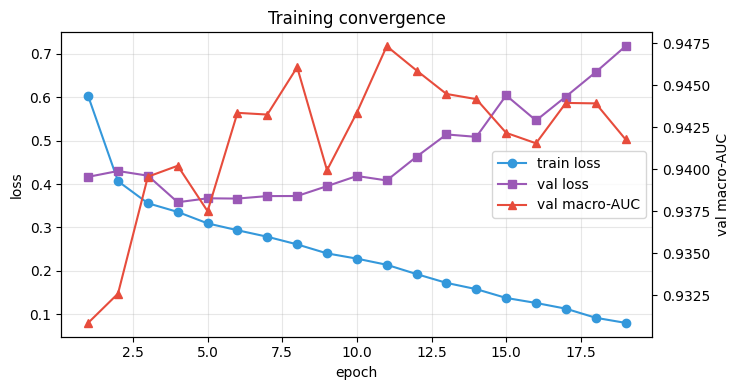

In [ ]:
fig, ax1 = plt.subplots(figsize=(7.5, 4))
ax1.plot(history['epoch'], history['train_loss'], 'o-', color='#3498db', label='train loss')
ax1.plot(history['epoch'], history['val_loss'],   's-', color='#9b59b6', label='val loss')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(history['epoch'], history['val_auc'], '^-', color='#e74c3c', label='val macro-AUC')
ax2.set_ylabel('val macro-AUC')
lines  = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center right')
ax1.set_title('Training convergence')
plt.tight_layout(); plt.show()

## Stage 4 — Evaluation on the Held-Out Test Set

Quantitative metrics first (macro-AUC, per-class AUC, ROC curves, classification report, confusion matrix), then qualitative views: per-joint-type accuracy, a sample-prediction gallery, and Grad-CAM heatmaps.

The **primary metric is macro-AUC (one-vs-rest)** — the assignment's stated metric. With heavy class imbalance, accuracy is misleading (predicting always-KL0 already gets ~74%); macro-AUC weights every KL grade equally.

In [ ]:
print("Stage 4: Evaluation")
print("=" * 60)

_, test_auc, test_preds, test_labels, test_probs = evaluate(test_loader)
print(f"Macro-average AUC (OvR): {test_auc:.4f}")
print(f"Overall accuracy       : {accuracy_score(test_labels, test_preds):.4f}\n")

# Per-class AUC
print(f"{'KL grade':<10}{'AUC':>8}{'Support':>10}")
per_class_auc = {}
for cls in range(NUM_CLASSES):
    support = int((test_labels == cls).sum())
    if 0 < support < len(test_labels):
        try:
            auc = roc_auc_score((test_labels == cls).astype(int), test_probs[:, cls])
            per_class_auc[cls] = auc
            print(f"  KL {cls}     {auc:>8.4f}{support:>10}")
        except ValueError:
            print(f"  KL {cls}     {'n/a':>8}{support:>10}")
    else:
        print(f"  KL {cls}     {'n/a':>8}{support:>10}  (only one class present)")

Stage 4: Evaluation
Macro-average AUC (OvR): 0.9450
Overall accuracy       : 0.8358

KL grade       AUC   Support
  KL 0       0.9418      4686
  KL 1       0.8398       664
  KL 2       0.9626       714
  KL 3       0.9844        52
  KL 4       0.9967        29


### ROC curves (one-vs-rest, per KL grade)

Per-class ROC curves and macro-average AUC. Each curve is the model's ability to separate that single KL grade from all others. **This is the assignment's primary visualization**, paired with the macro-AUC number above.

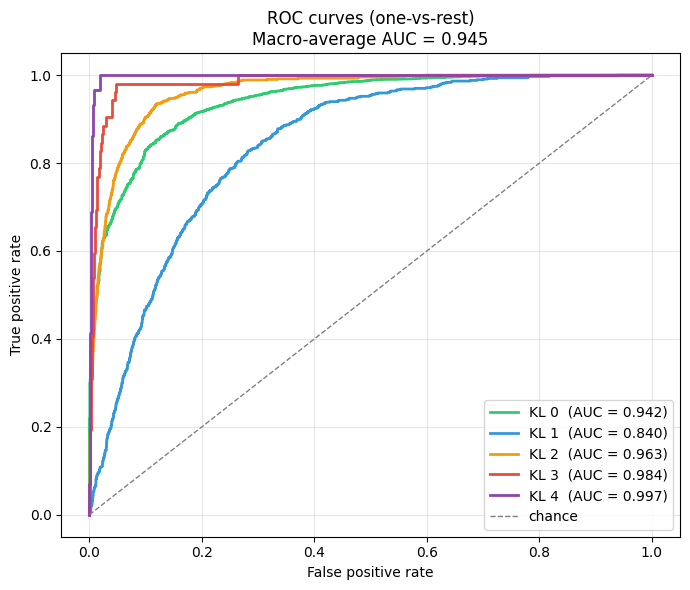

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
roc_colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#8e44ad']
for cls in range(NUM_CLASSES):
    if cls in per_class_auc:
        y_true = (test_labels == cls).astype(int)
        fpr, tpr, _ = roc_curve(y_true, test_probs[:, cls])
        ax.plot(fpr, tpr, color=roc_colors[cls], lw=2,
                label=f'KL {cls}  (AUC = {per_class_auc[cls]:.3f})')
ax.plot([0,1], [0,1], '--', color='gray', lw=1, label='chance')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title(f'ROC curves (one-vs-rest)\nMacro-average AUC = {test_auc:.3f}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Classification report

In [ ]:
print(classification_report(
    test_labels, test_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=[f"KL{i}" for i in range(NUM_CLASSES)],
    zero_division=0,
))

              precision    recall  f1-score   support

         KL0       0.93      0.93      0.93      4686
         KL1       0.37      0.38      0.38       664
         KL2       0.71      0.69      0.70       714
         KL3       0.38      0.40      0.39        52
         KL4       0.45      0.52      0.48        29

    accuracy                           0.84      6145
   macro avg       0.57      0.58      0.58      6145
weighted avg       0.84      0.84      0.84      6145



### Confusion matrix

Most off-diagonal mass should sit on the **adjacent** sub-diagonals — that is, the model's mistakes should be off-by-one, which is consistent with the inter-grade ambiguity radiologists themselves disagree on.

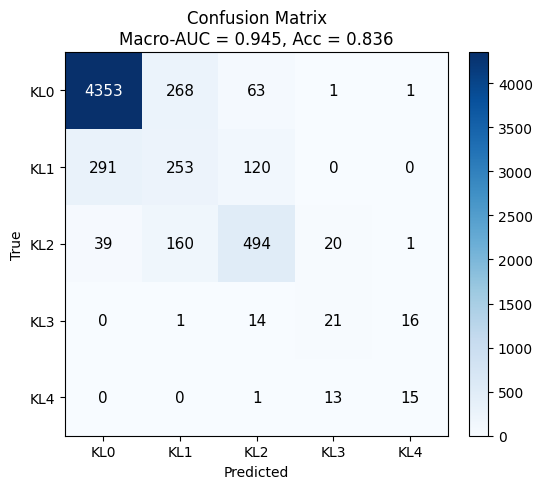

In [ ]:
cm = confusion_matrix(test_labels, test_preds, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', aspect='equal')
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels([f"KL{i}" for i in range(NUM_CLASSES)])
ax.set_yticklabels([f"KL{i}" for i in range(NUM_CLASSES)])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix\nMacro-AUC = {test_auc:.3f}, "
             f"Acc = {accuracy_score(test_labels, test_preds):.3f}")
vmax = cm.max()
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        v = cm[i, j]
        ax.text(j, i, str(v), ha='center', va='center',
                color='white' if v > vmax/2 else 'black', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

### Per-joint-type accuracy (DIP / PIP / MCP)

DIP, PIP, and MCP joints differ in OA prevalence and bone morphology (DIP joints are typically affected first in HOA). Breaking accuracy out by joint type is a quick sanity check on whether the model is biased toward the easier types.

In [ ]:
test_joints = np.array([d[0].split('_')[1].replace('.png','') for d in test_data])

print(f"  {'Joint':<6}{'N':>6}    {'Accuracy':>10}")
for jt in ['dip', 'pip', 'mcp']:
    mask = np.char.startswith(test_joints, jt)
    n = int(mask.sum())
    if n > 0:
        acc = accuracy_score(test_labels[mask], test_preds[mask])
        print(f"  {jt.upper():<6}{n:>6}    {acc:>10.4f}")

  Joint      N      Accuracy
  DIP     1966        0.7843
  PIP     2058        0.7901
  MCP     2121        0.9279


### Sample test predictions

Grid of correct (green border) and incorrect (red border) predictions across all KL grades, with the model's confidence. Most red borders should show off-by-one mistakes (e.g. true KL 1 → pred KL 2), which matches what we see in the confusion matrix.

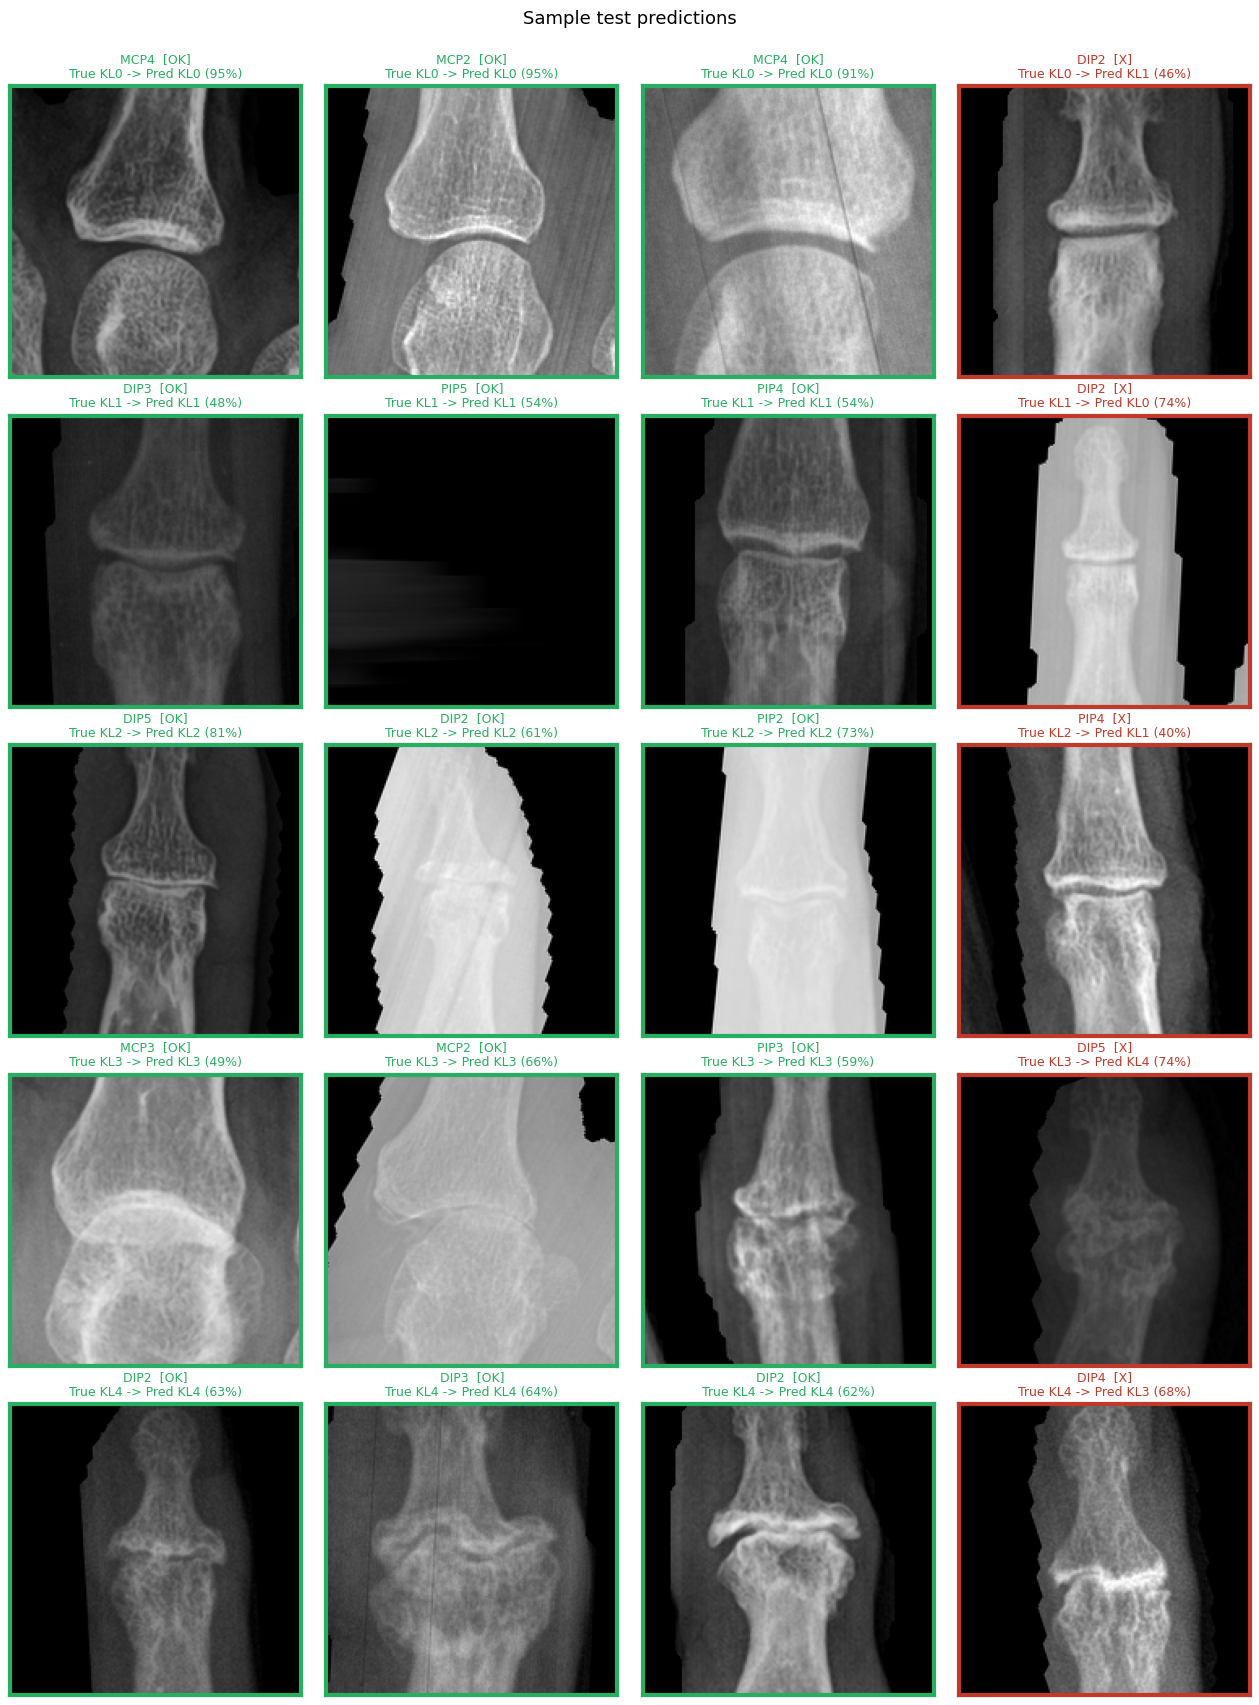

In [ ]:
# Pick up to 3 correct + 1 incorrect per KL grade
N_CORRECT, N_INCORRECT = 3, 1
rng = np.random.default_rng(SEED)

correct_idx, incorrect_idx = {c: [] for c in range(NUM_CLASSES)}, {c: [] for c in range(NUM_CLASSES)}
for i, true_lbl in enumerate(test_labels):
    bucket = correct_idx if test_preds[i] == true_lbl else incorrect_idx
    bucket[int(true_lbl)].append(i)

gallery = []
for c in range(NUM_CLASSES):
    if correct_idx[c]:
        gallery.extend(int(x) for x in rng.choice(
            correct_idx[c], size=min(N_CORRECT, len(correct_idx[c])), replace=False))
    if incorrect_idx[c]:
        gallery.extend(int(x) for x in rng.choice(
            incorrect_idx[c], size=min(N_INCORRECT, len(incorrect_idx[c])), replace=False))

def _img_for(fname):
    return shared_cache[fname] if (shared_cache and fname in shared_cache) else _load_pil(fname)

n_imgs, n_cols = len(gallery), 4
n_rows = int(np.ceil(n_imgs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.2, n_rows*3.4))
axes = np.atleast_2d(axes)

for ax_i, idx in enumerate(gallery):
    r, c = ax_i // n_cols, ax_i % n_cols
    ax = axes[r, c]
    fname, true_label = test_data[idx]
    pred = int(test_preds[idx]); conf = float(test_probs[idx, pred])
    correct = pred == true_label
    edge = '#27ae60' if correct else '#c0392b'
    ax.imshow(_img_for(fname), cmap='gray')
    for spine in ax.spines.values():
        spine.set_edgecolor(edge); spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])
    joint = fname.split('_')[1].replace('.png','').upper()
    mark  = "OK" if correct else "X"
    ax.set_title(f"{joint}  [{mark}]\nTrue KL{true_label} -> Pred KL{pred} ({conf:.0%})",
                 fontsize=9, color=edge)

# Hide any unused axes
for ax_i in range(n_imgs, n_rows*n_cols):
    axes[ax_i // n_cols, ax_i % n_cols].axis('off')

plt.suptitle("Sample test predictions", fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

### Grad-CAM heatmaps

Grad-CAM (Selvaraju et al., 2017) shows which pixels drove the model's decision: it weights the last-conv feature maps by the gradient of the target-class logit, applies ReLU, and upsamples to image size. On a well-trained model, attention should concentrate on the **joint space** (the gap between the two bones) and the osteophyte-prone bone edges — i.e. the same anatomical features a radiologist uses for KL grading.

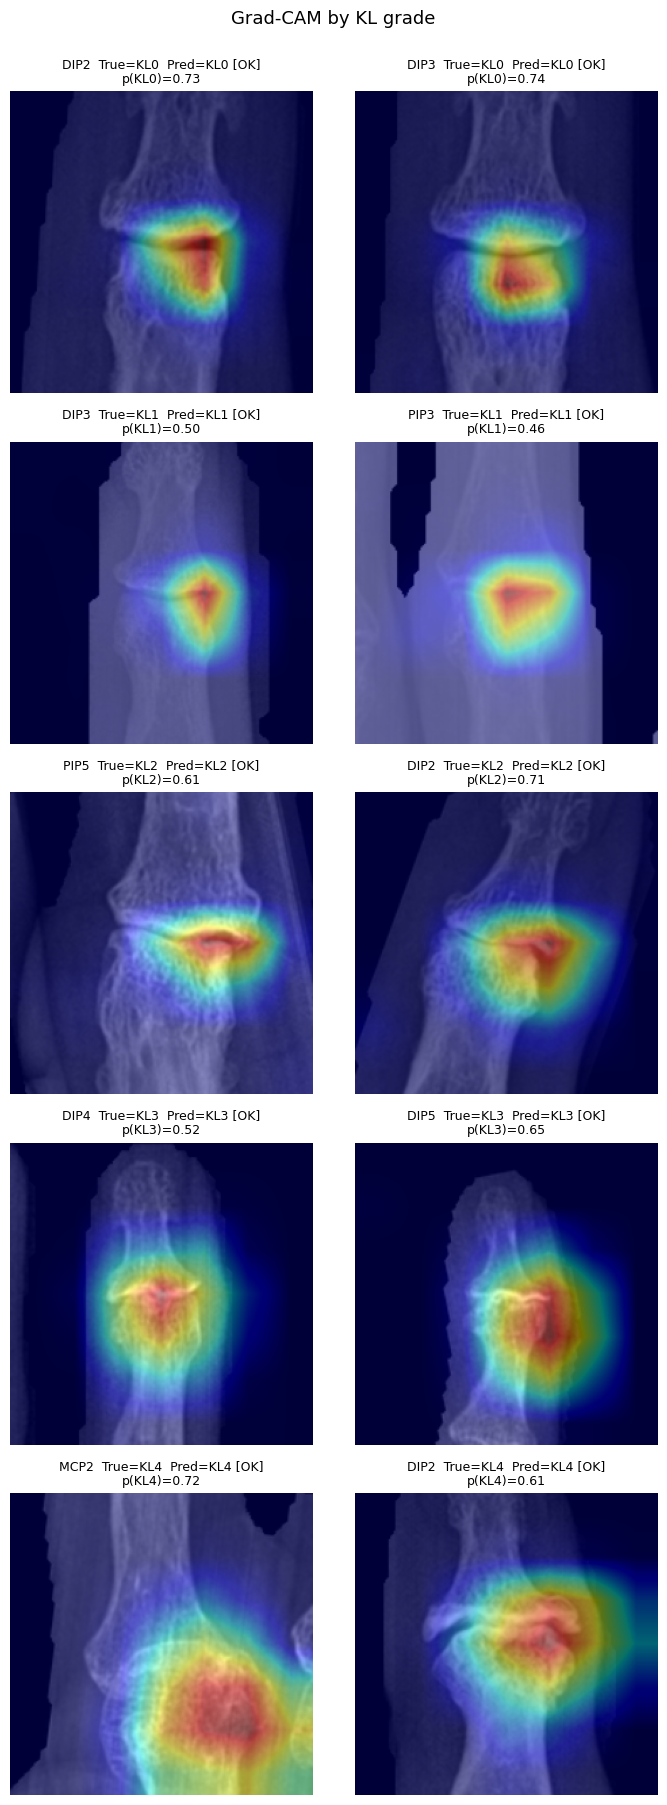

In [ ]:
class GradCAM:
    """Selvaraju et al. (2017) Grad-CAM on a single conv layer."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations, self.gradients = None, None
        self.fh = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        self.bh = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))
    def __call__(self, x, class_idx):
        self.model.zero_grad()
        out = self.model(x)
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        probs = F.softmax(out, dim=1)[0].detach().cpu().numpy()
        return cam, probs
    def close(self):
        self.fh.remove(); self.bh.remove()

# Pick 2 examples per KL grade; prefer correct predictions, then fall back to any
N_PER_CLASS = 2
selected = {c: [] for c in range(NUM_CLASSES)}
for idx, ((fname, label), pred) in enumerate(zip(test_data, test_preds)):
    if len(selected[label]) < N_PER_CLASS and pred == label:
        selected[label].append((idx, fname, label, int(pred)))
for c in range(NUM_CLASSES):
    if len(selected[c]) < N_PER_CLASS:
        for idx, (fname, label) in enumerate(test_data):
            if label == c and not any(s[0] == idx for s in selected[c]):
                selected[c].append((idx, fname, label, int(test_preds[idx])))
                if len(selected[c]) >= N_PER_CLASS: break

# Last conv block differs by architecture; pick the right one.
if MODEL_NAME.lower() == 'resnet50':
    target_layer = model.layer4[-1]
elif MODEL_NAME.lower() == 'efficientnet_b2':
    target_layer = model.features[-1]
else:
    raise ValueError(f"No Grad-CAM target layer configured for MODEL_NAME={MODEL_NAME!r}.")
gradcam = GradCAM(model, target_layer)
model.eval()

fig, axes = plt.subplots(NUM_CLASSES, N_PER_CLASS, figsize=(N_PER_CLASS*3.6, NUM_CLASSES*3.6))
mean_t, std_t = torch.tensor(MEAN).view(3,1,1), torch.tensor(STD).view(3,1,1)

for c in range(NUM_CLASSES):
    for j in range(N_PER_CLASS):
        ax = axes[c, j] if N_PER_CLASS > 1 else axes[c]
        if j >= len(selected[c]):
            ax.axis('off'); continue
        _, fname, true_label, pred = selected[c][j]
        img_pil = _img_for(fname)
        img_t   = eval_tf(img_pil)
        x       = img_t.unsqueeze(0).to(device, memory_format=torch.channels_last)
        cam, probs = gradcam(x, class_idx=true_label)
        img_disp = (img_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
        heatmap  = mpl_cm.jet(cam)[:, :, :3]
        overlay  = np.clip(0.55 * img_disp + 0.45 * heatmap, 0, 1)
        ax.imshow(overlay); ax.axis('off')
        joint = fname.split('_')[1].replace('.png','').upper()
        mark  = "OK" if pred == true_label else "X"
        ax.set_title(f"{joint}  True=KL{true_label}  Pred=KL{pred} [{mark}]\n"
                     f"p(KL{true_label})={probs[true_label]:.2f}", fontsize=9)

plt.suptitle("Grad-CAM by KL grade", fontsize=13, y=1.00)
plt.tight_layout(); plt.show()
gradcam.close()

## Final Report

### Challenges

Hand-OA KL classification on this dataset is hard for reasons that are mostly *not* about the model architecture — they're about the data. The challenges below are the ones that actually shaped our design decisions:

- **Severe class imbalance (~125 : 1 in the train split).** The training set contains 22,094 KL 0 examples versus 176 KL 4 examples. A vanilla cross-entropy classifier collapses to "always predict KL 0" and scores ~77% accuracy while being clinically useless (it never flags a single severe case). We addressed this with **class-weighted focal loss** (Lin et al., 2017) — `α_c · (1 − p_t)^γ · (−log p_t)` with `α_c = √(N_max / N_c)` and `γ = 2`. The `(1 − p_t)^γ` term down-weights easy, already-correct examples (the abundant KL 0s) so gradient concentrates on hard / minority cases, while `α_c` rebalances class frequency on top of that.
- **Subtle, ordinal visual differences between adjacent KL grades.** KL 0 → KL 1 → KL 2 is a continuum of joint-space narrowing and incipient osteophyte formation that radiologists themselves disagree on; the boundary between KL 1 and KL 2 is the single most contested call in clinical KL grading. We expected — and saw — most errors to land off-by-one. Direct multi-class with focal loss handles this well enough for a baseline; explicit ordinal modeling is the natural next step.
- **Patient-level data leakage risk.** A single patient contributes up to 12 joint ROIs across both hands that share anatomy, exposure, and disease background. A naive image-level split puts a patient's index-finger DIP in train and pinky DIP in test, leaks information, and inflates metrics. We split **patients** (not images) 70/15/15 and stratify on each patient's *worst* KL grade so the few KL 3 / KL 4 patients are spread evenly across train/val/test rather than all landing in one bucket.
- **Missing labels and missing PNGs.** Some `hand.csv` rows lack KL annotations; some reference filenames not on disk. We filter both at record-build time and log the count rather than letting them blow up at training time.
- **Google Drive I/O is slow per file.** Reading 28k training PNGs from Drive on every epoch dominates wall-clock time. We load each PNG once with an 8-thread pool into a module-level RAM cache and reuse it across epochs (and across re-runs of the cell). First-run caching takes hours; every subsequent epoch is GPU-bound.
- **Small absolute counts for KL 3 / KL 4 even after rebalancing.** The held-out test set has only 52 KL 3 and 29 KL 4 examples, so per-class metrics for those grades carry real sample-size noise. We report macro-AUC as the headline rather than per-class precision/recall and treat the rare-class numbers as indicative rather than tight.

---

### Results

**Setup.** Trained on **3,590 patients / 41,075 joint annotations** with a 70/15/15 patient-level split (28,756 train / 6,174 val / 6,145 test). ResNet-50 backbone (ImageNet-pretrained, fully fine-tuned, 23.5 M params), class-weighted focal loss (γ = 2), AdamW (`lr = 1e-4`, `weight_decay = 1e-4`) with cosine annealing, mixed-precision training, batch size 64. Training early-stopped after **19 epochs** (best validation macro-AUC **0.9473** at epoch 11; total wall-clock 1h08m on a Colab T4).

**Headline metrics on the held-out test set:**

| Metric                         | Value      |
|--------------------------------|------------|
| **Macro-average AUC (OvR)**    | **0.9450** |
| Overall accuracy               | 0.8358     |

**Per-class AUC (one-vs-rest):**

| KL grade | AUC    | Test support |
|----------|--------|--------------|
| KL 0     | 0.9418 | 4,686        |
| KL 1     | 0.8398 |   664        |
| KL 2     | 0.9626 |   714        |
| KL 3     | 0.9844 |    52        |
| KL 4     | 0.9967 |    29        |

**Argmax classification report:**

| Class         | Precision | Recall | F1   | Support |
|---------------|-----------|--------|------|---------|
| KL 0          | 0.93      | 0.93   | 0.93 | 4,686   |
| KL 1          | 0.37      | 0.38   | 0.38 |   664   |
| KL 2          | 0.71      | 0.69   | 0.70 |   714   |
| KL 3          | 0.38      | 0.40   | 0.39 |    52   |
| KL 4          | 0.45      | 0.52   | 0.48 |    29   |
| **Macro avg** | 0.57      | 0.58   | 0.58 | 6,145   |
| Weighted avg  | 0.84      | 0.84   | 0.84 | 6,145   |

**Per-joint-type accuracy:**

| Joint | N     | Accuracy |
|-------|-------|----------|
| DIP   | 1,966 | 0.7843   |
| PIP   | 2,058 | 0.7901   |
| MCP   | 2,121 | 0.9279   |

**Reading the numbers:**

- **Macro-AUC of 0.945** is a strong result for a 5-class clinical-grading task with 132 : 1 imbalance — comparable to published knee-OA KL classifiers (typically 0.85–0.95). It substantially beats the always-predict-KL 0 baseline (77% accuracy, macro-AUC 0.5).
- **KL 1 is by far the hardest class** (AUC 0.840, F1 0.38). The confusion matrix shows KL 1 examples bleed roughly evenly into KL 0 and KL 2 — exactly the boundary that radiologists themselves disagree on most. This is the largest piece of remaining headroom.
- **KL 3 and KL 4 have the highest AUCs** (0.984 and 0.997). Their *ranked* probabilities separate very cleanly from healthy joints — the more clinically meaningful signal, since rare-but-severe cases get flagged. Argmax precision/recall is lower (~0.4) because the rare classes still occasionally get over-ridden by the more confident KL 0 / KL 2 logits at the argmax; per-class threshold calibration would close most of that gap without retraining.
- **Errors are overwhelmingly off-by-one between adjacent grades.** Almost no KL 0 examples are predicted as KL 3 or KL 4 and vice versa — the model has learned the gross severity ordering even without an explicit ordinal head.
- **MCP joints are notably easier than DIP / PIP** (92.8% vs 78.4% / 79.0%). MCP joints are predominantly healthy in HOA, so the model scores well on them mostly by predicting KL 0 — the DIP / PIP numbers are a more honest readout of real grading skill.
- **Grad-CAM heatmaps** confirm the model attends to the joint space and the osteophyte-prone bone edges — the same anatomy a radiologist looks at — rather than to image artifacts, ROI borders, or background gradient.

---

### Conclusions

The four-stage pipeline (Data Preparation → Feature Extraction → Training → Evaluation) produces a model that classifies KL severity from a single finger-joint ROI at **macro-AUC 0.945** on a held-out, patient-disjoint test set. The combination of patient-level stratified splitting, class-weighted focal loss, ImageNet transfer learning, Grad-CAM interpretability addresses, and the per-class AUCs (0.84–0.997) show the model has learned genuine signal across all five grades despite the 132 : 1 imbalance.

The two clear directions for remaining headroom are (1) the KL 0 / KL 1 / KL 2 boundary, which is the same place clinical inter-rater agreement is lowest, and (2) calibration of the rare classes — KL 3 and KL 4 already separate cleanly under AUC, but their argmax predictions would benefit from per-class threshold tuning. Both are well-understood directions rather than open research problems, which makes this an honest baseline to build on rather than a final answer.

If we had more time, the highest-leverage next steps would be:

- **Ordinal regression head** (or an ordinal-aware loss like CORN). KL is ordered, and explicitly modeling that order would penalize KL 0 → KL 4 mistakes more than KL 0 → KL 1 mistakes — closer to clinical intuition, and likely to help the KL 1 confusion specifically.
- **ResNet-50 vs. EfficientNet-B2 head-to-head.** The proposal commits to comparing both. The notebook supports either via `MODEL_NAME`; running it twice and putting the macro-AUC / per-class AUC side by side is the natural extension we did not get to.
- **Per-class decision-threshold tuning.** AUC for KL 3 / KL 4 is very high (0.98 / 0.997) but argmax-based precision/recall is lower (~0.4). Calibrating per-class thresholds on the validation set would close that gap without retraining.
- **Multi-label head** predicting KL, JSN, and OP from the same backbone. The auxiliary losses act as regularizers and force the model to attend to underlying anatomy rather than memorize KL shortcuts.
- **k-fold cross-validation** specifically for tighter confidence intervals on KL 3 / KL 4 AUC, which are otherwise dominated by sample-size noise (29 KL 4 examples in the test fold).
